In [25]:
import os
from os import listdir
import pandas as pd
import numpy as np
import glob
import cv2
import json
from os.path import expanduser


from tqdm import tqdm

import torch 
from torchvision import models
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn 
import torchvision.transforms as transforms
from torchsummary import summary

from sklearn.model_selection import train_test_split


import matplotlib.pyplot as plt 
from PIL import Image


In [26]:
home = expanduser("~")

parent_path =  home + "/Pictures/" + "Data/"

root_dir = parent_path + "merge_folder-2022-11-03-18-32"

In [27]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


In [28]:
from imgaug.augmentables.kps import KeypointsOnImage
from imgaug.augmentables.kps import Keypoint
import imgaug.augmenters as iaa

In [29]:
all_img_paths = glob.glob(os.path.join(root_dir, '*.jpg'))


data = pd.read_csv(parent_path + 'new_kps_results_v1.csv')

print(type(data))

doc = data.iloc[4221][1]

print(doc)

data.head(100)

<class 'pandas.core.frame.DataFrame'>
3486.jpg


,id,image_rgb,keypoints/0/0,keypoints/0/1,keypoints/1/0,keypoints/1/1,keypoints/2/0,keypoints/2/1,keypoints/3/0,keypoints/3/1,keypoints/4/0,keypoints/4/1,keypoints/5/0,keypoints/5/1
0,4153,4153.jpg,231.226337,442.172945,223.173674,318.370417,131.094812,249.320380,150.012911,225.599536,123.861384,90.366689,110.941161,62.925795
1,2656,2656.jpg,231.226337,442.172945,223.173674,318.370417,204.601658,205.795581,234.160140,200.990828,299.252165,81.107571,306.627134,52.401656
2,8106,8106.jpg,231.226337,442.172945,223.173674,318.370417,119.085336,267.880784,133.292749,241.017516,276.124076,251.991037,307.338761,247.001238
3,4607,4607.jpg,231.226337,442.172945,223.173674,318.370417,196.867093,207.352276,226.079512,200.568637,290.965527,80.446041,298.262087,51.716569
4,2927,2927.jpg,231.226337,442.172945,223.173674,318.370417,161.461260,222.115555,187.149668,206.253604,253.783708,86.011751,261.432991,57.279039
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,5480,5480.jpg,231.226337,442.172945,223.173674,318.370417,317.413677,252.378475,334.498450,276.608393,470.784400,306.459968,501.483675,305.677744
96,5437,5437.jpg,231.226337,442.172945,223.173674,318.370417,317.414821,252.380101,334.499165,276.610322,472.244943,297.537001,502.753978,294.763900
97,2485,2485.jpg,231.226337,442.172945,223.173674,318.370417,173.229176,215.668817,200.482469,202.831234,266.604089,82.758951,274.159172,54.051582
98,2233,2233.jpg,231.226337,442.172945,223.173674,318.370417,134.745994,244.899289,154.777550,222.130071,222.545409,100.986986,230.392655,72.092352


In [30]:
img_arr = cv2.imread(os.path.join(root_dir, '3717.jpg'))

print(img_arr.shape)

img_arr = img_arr[:,:,::-1] 

(480, 640, 3)


keypoints/0/0    231.226337
keypoints/1/0    223.173674
keypoints/2/0    119.084295
keypoints/3/0    133.291314
keypoints/4/0    276.312022
keypoints/5/0    307.406648
Name: 1962, dtype: object
keypoints/0/1    442.172945
keypoints/1/1    318.370417
keypoints/2/1    267.882604
keypoints/3/1    241.019103
keypoints/4/1    249.296226
keypoints/5/1    243.725379
Name: 1962, dtype: object


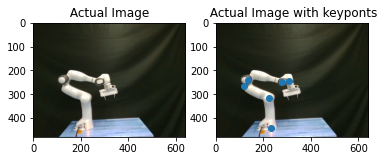

In [31]:
x_points = data.iloc[1962][2:][::2]
y_points = data.iloc[1962][3:][::2]

print(x_points)
print(y_points)

plt.subplot(121)
plt.imshow(img_arr)
plt.title(" Actual Image ")
plt.subplot(122)
plt.imshow(img_arr)
plt.scatter(list(x_points), list(y_points))
plt.title(" Actual Image with keyponts")
plt.show()

In [32]:
class KpDataset(Dataset):
    def __init__(self, df):
        super().__init__()
        self.normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                              std=[0.229, 0.224, 0.225])
        self.df = df

    def __getitem__(self, ix):
        doc = self.df.iloc[ix]
        image_name = doc[1]
        image_path = os.path.join(root_dir,image_name)  
        img_arr = cv2.imread(image_path)
        x_axis_points = doc[2:][::2]
        y_axis_points = doc[3:][::2]
        x_axis_points = list(x_axis_points/img_arr.shape[1])           # scaling the facial points with respective image_dim 
        y_axis_points = list(y_axis_points/img_arr.shape[0])           # so that we can use relative positions w.r.t image

        points = x_axis_points + y_axis_points  

        img_arr = img_arr/255.0                                                                 # scaling the image 
        img = self.preprocess_img(img_arr)

        return img.to(device), torch.tensor(points).to(device)

    def __len__(self):
        return self.df.shape[0]


    def preprocess_img(self, img):
        img = cv2.resize(img, (224,224)) 
        img = torch.tensor(img).permute(2,0,1) 
        img = self.normalize(img).float()
        return img

    def load_img(self, ix):
        doc = self.df.iloc[ix]
        img_name = doc[1]
        img = cv2.imread(os.path.join(root_dir, img_name))
        return img

In [33]:
train_df, rem_df = train_test_split(data, train_size=0.8)

val_df, test_df = train_test_split(rem_df, test_size=0.5)

# print(len(train_df))
# print(test_df)
# print(train_df.shape)
# print(test_df.shape)
# print(val_df.shape)


In [34]:
train_dataset = KpDataset(train_df)
val_dataset = KpDataset(val_df)
test_dataset = KpDataset(test_df)

# print(train_dataset[8])
# print(val_dataset[8])

In [35]:
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=32, shuffle=True)

In [36]:
for img, points in train_dataloader:
    print(img.shape)
    print(points.shape)
    break

torch.Size([32, 3, 224, 224])
torch.Size([32, 12])


In [37]:
model = models.vgg19(pretrained=True)

/home/jc-merlab/.local/lib/python3.8/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and will be removed in 0.15, please use 'weights' instead.
  warnings.warn(
/home/jc-merlab/.local/lib/python3.8/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and will be removed in 0.15. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [38]:
model

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padd

In [39]:
for param in model.parameters():
      param.requires_grad = False

In [40]:
from torch.nn.modules.activation import Sigmoid
from torch.nn.modules.pooling import AdaptiveAvgPool2d
pool_layer = nn.Sequential(
     nn.Conv2d(512,512, kernel_size=3, padding='same'),
     nn.ReLU(),
     nn.MaxPool2d(kernel_size=2, stride=2),
     nn.Conv2d(512,50, kernel_size=3, padding='same'),
     nn.ReLU(),
     nn.MaxPool2d(kernel_size=2, stride=2),
     nn.AdaptiveAvgPool2d(output_size=(8,8))
)

model.avgpool = pool_layer

final_predictor = nn.Sequential(
    nn.Linear(3200, 300),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(300, 12),
    nn.Sigmoid()
)

model.classifier = final_predictor

In [41]:
model = model.to(device)


In [42]:
model


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padd

In [43]:
summary(model, torch.rand(1,3,224,224))

TypeError: rand(): argument 'size' must be tuple of ints, but found element of type Tensor at pos 2

In [44]:
# getting the optimizer and loss_function 

def get_essentials():
    loss_fun = nn.L1Loss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)
    return loss_fun, optimizer


In [45]:
# defining batch_train and accuracy functions

def train_batch(data, model, loss_fun, optimizer):
    model.train()
    img, true_points = data
    pred_points = model(img)
    loss_val = loss_fun(pred_points, true_points)
    loss_val.backward()
    optimizer.step()
    optimizer.zero_grad()
    return loss_val.item()

@torch.no_grad()
def val_batch(data, model, loss_fun, optimizer):
    model.eval()
    img, true_points = data
    pred_points = model(img)
    loss_val = loss_fun(pred_points, true_points)
    return loss_val.item()

In [46]:
epochs = 30
loss_fun, optimizer = get_essentials()

In [47]:
# training and validation loops 


train_epoch, val_epoch = [], []
for epoch in tqdm(range(epochs)):
    train_batch_losses, val_batch_losses = [], []
    for data in train_dataloader:
        train_batch_loss = train_batch(data, model, loss_fun, optimizer)
        train_batch_losses.append(train_batch_loss)
    for data in val_dataloader:
        val_batch_loss = val_batch(data, model, loss_fun, optimizer)
        val_batch_losses.append(val_batch_loss)
    train_epoch.append(np.mean(train_batch_losses))
    val_epoch.append(np.mean(val_batch_losses))

100%|███████████████████████████████████████████| 30/30 [29:21<00:00, 58.73s/it]


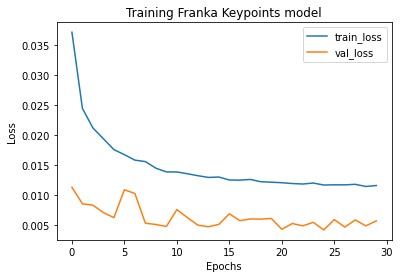

In [48]:
plt.plot(range(epochs), train_epoch, label="train_loss")
plt.plot(range(epochs), val_epoch, label="val_loss")
plt.legend()
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Franka Keypoints model")
plt.show()

In [49]:
# Specify a path
PATH = parent_path + "entire_model_vgg19_30.pth"

# Save
torch.save(model, PATH)

torch.Size([3, 224, 224])
tensor([0.3613, 0.3487, 0.1950, 0.2211, 0.3657, 0.3875, 0.9212, 0.6633, 0.5377,
        0.4848, 0.2646, 0.2087], device='cuda:0', dtype=torch.float64)
tensor([0.3585, 0.3456, 0.1896, 0.2142, 0.3592, 0.3823, 0.9284, 0.6665, 0.5445,
        0.4902, 0.2652, 0.2049])
tensor([1.0754, 1.0367, 0.5688, 0.6427, 1.0775, 1.1470])
tensor([29.7090, 21.3277, 17.4243, 15.6851,  8.4852,  6.5571])
0.008516550064086914
<class 'torch.Tensor'>
(480, 640, 3)
(480, 640, 3)


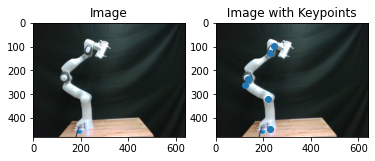

In [50]:
# Displaying the results
import time
test_dataset = KpDataset(test_df)
index = 0
test_img, points = test_dataset[index]
print(test_img.shape)
print(points)
s = time.time()
franka_key_points = model(test_img[None]).flatten().detach().cpu()
print(franka_key_points)

fkpy = franka_key_points[:6]*img.shape[1]
fkpx = franka_key_points[6:]*img.shape[0]

print(fkpy)
print(fkpx)

curr_time = (time.time()-s )
print(curr_time)
print(type(franka_key_points))
plt.subplot(121)
plt.title("Image")
img = test_dataset.load_img(index)
print(img.shape)
# img = img[:,:,::-1]
print(img.shape)
plt.imshow(img)
plt.subplot(122)
plt.title(" Image with Keypoints ")
plt.imshow(img)
plt.scatter(franka_key_points[:6]*img.shape[1], franka_key_points[6:]*img.shape[0])   # scaling the keypoints with image dimension
plt.show()

In [51]:
import cv2

normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                              std=[0.229, 0.224, 0.225])
# img = cv2.imread('/home/jc-merlab/Deep_Learning/merlab_dl_data/2D_proj_ds/61.rgb.jpg')

img = cv2.imread('/home/jc-merlab/frame0000.jpg')

# img = cv2.imread('/home/jc-merlab/Deep_Learning/merlab_dl_data/test_img.jpg')

print(img.shape)

img_arr = img/255.0
img_arr = cv2.resize(img_arr, (224,224)) 
img_arr = torch.tensor(img_arr).permute(2,0,1) 
print(type(img_arr))
img_arr = normalize(img_arr).float()
img_arr = img_arr.to(device)
# img = list(img)


(480, 640, 3)
<class 'torch.Tensor'>


In [52]:
print(img_arr.shape)

torch.Size([3, 224, 224])


In [53]:
franka_key_points = model(img_arr[None]).flatten().detach().cpu()

print(franka_key_points)

fkpx = franka_key_points[:6]*img.shape[1]

print(fkpx)

fkpy = franka_key_points[6:]*img.shape[0]

print(fkpy)

tensor([0.4212, 0.4080, 0.4064, 0.4334, 0.5421, 0.5700, 0.7701, 0.6004, 0.4685,
        0.4611, 0.4428, 0.4258])
tensor([269.5750, 261.0907, 260.1257, 277.3623, 346.9263, 364.7917])
tensor([369.6539, 288.1917, 224.8961, 221.3331, 212.5218, 204.3843])


640


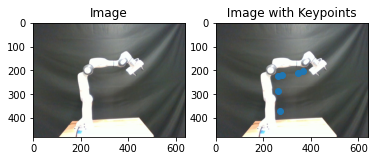

In [54]:
# img = cv2.imread('/home/jc-merlab/Deep_Learning/merlab_dl_data/2D_proj_ds/61.rgb.jpg')

# img = cv2.imread('/home/jc-merlab/Deep_Learning/merlab_dl_data/test_img.jpg')

img = cv2.imread('/home/jc-merlab/frame0000.jpg')
img = img[:,:,::-1] 
print(img.shape[1])
plt.subplot(121)
plt.title("Image")                                                        
plt.imshow(img)
plt.subplot(122)
plt.title(" Image with Keypoints ")
plt.imshow(img)
plt.scatter(franka_key_points[:6]*img.shape[1], franka_key_points[6:]*img.shape[0])   # scaling the keypoints with image dimension
plt.show()